In [41]:
import matplotlib.pyplot as plt
import pandas as pd
data = pd.read_csv('pub_year.csv')
data.head(10)


,Year,n
0,2006,1
1,2017,1
2,2020,2
3,2021,5
4,2022,6
5,2023,7
6,2024,11
7,2025,7


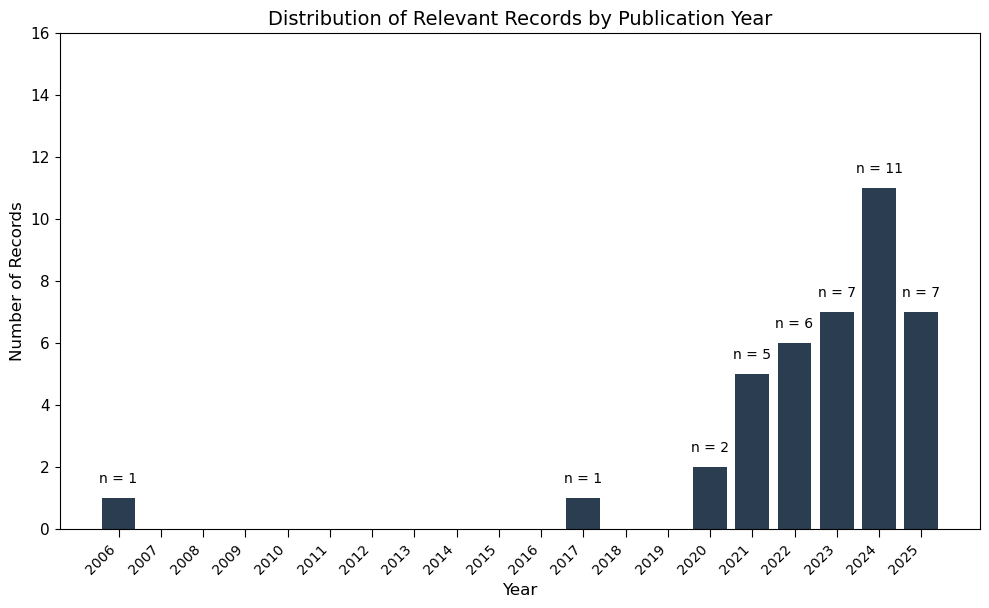

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure data is in a DataFrame
df = pd.DataFrame({"Year": data["Year"], "n": data["n"]})

# Fill in all years (including missing ones) with 0 if not present
full_year_range = range(df["Year"].min(), df["Year"].max() + 1)
df_full = pd.DataFrame({"Year": full_year_range})
df_merged = df_full.merge(df, on="Year", how="left").fillna(0)
df_merged["n"] = df_merged["n"].astype(int)

x = df_merged["Year"]
y = df_merged["n"]

# Set figure size using golden ratio
plt.figure(figsize=(10, 6.18))

# Create vertical bar chart with all years
bars = plt.bar(x, y, color="#2B3D50")

# Function to add value labels above bars (only where n > 0)
def add_labels(x, y):
    for i in range(len(x)):
        if y[i] > 0:
            plt.text(x[i], y[i] + 0.5, f"n = {y[i]}", ha='center', fontsize=10)

add_labels(x, y)

# Titles and axis labels
plt.title("Distribution of Relevant Records by Publication Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)

# Ticks and labels for every year
plt.xticks(full_year_range, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=11)
plt.gca().set_xticks(full_year_range)  # Ensure tick marks for every year
plt.gca().tick_params(axis='x', which='major', length=6)

plt.ylim(0, max(y) + 5)
plt.tight_layout()
plt.show()